*https://www.kaggle.com/datasets/raghupalem/bill_authentication*

# **Importing libraries and loading the dataset**

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import requests
import warnings
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.decomposition import PCA
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
requests.packages.urllib3.disable_warnings()
warnings.filterwarnings("ignore")
%matplotlib inline

In [50]:
data = pd.read_csv("bill_authentication.csv")

In [51]:
data.head()

,Variance,Skewness,Curtosis,Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [52]:
data

,Variance,Skewness,Curtosis,Entropy,Class
0,3.62160,8.66610,-2.8073,-0.44699,0
1,4.54590,8.16740,-2.4586,-1.46210,0
2,3.86600,-2.63830,1.9242,0.10645,0
3,3.45660,9.52280,-4.0112,-3.59440,0
4,0.32924,-4.45520,4.5718,-0.98880,0
...,...,...,...,...,...
1367,0.40614,1.34920,-1.4501,-0.55949,1
1368,-1.38870,-4.87730,6.4774,0.34179,1
1369,-3.75030,-13.45860,17.5932,-2.77710,1
1370,-3.56370,-8.38270,12.3930,-1.28230,1


In [53]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Variance  1372 non-null   float64
 1   Skewness  1372 non-null   float64
 2   Curtosis  1372 non-null   float64
 3   Entropy   1372 non-null   float64
 4   Class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


# **Visualization**

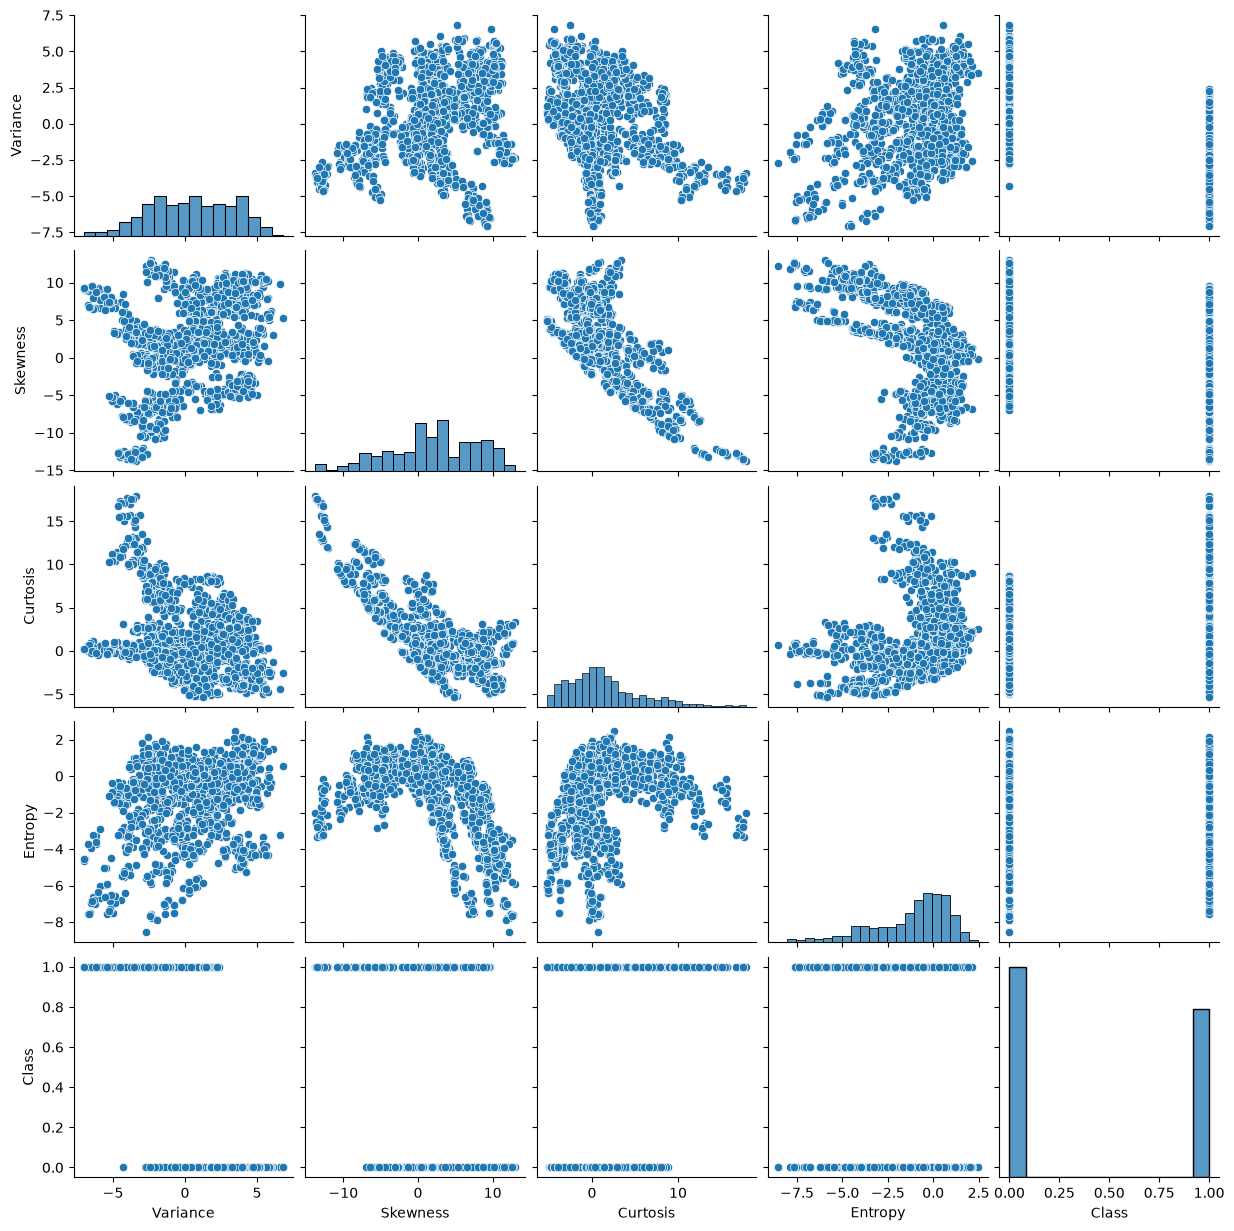

In [54]:
sns.pairplot(data)

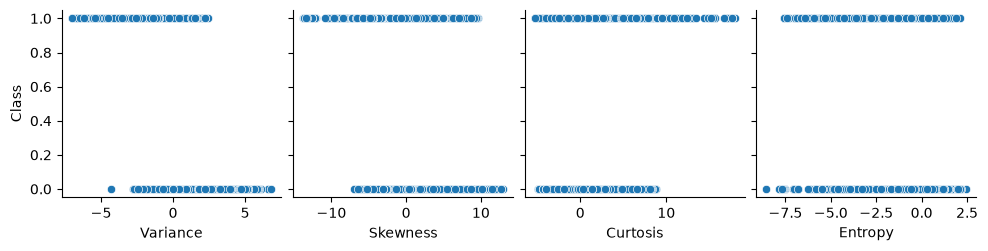

In [55]:
sns.pairplot(data,x_vars=['Variance','Skewness','Curtosis','Entropy'],y_vars=['Class'],kind='scatter')

<Axes: >

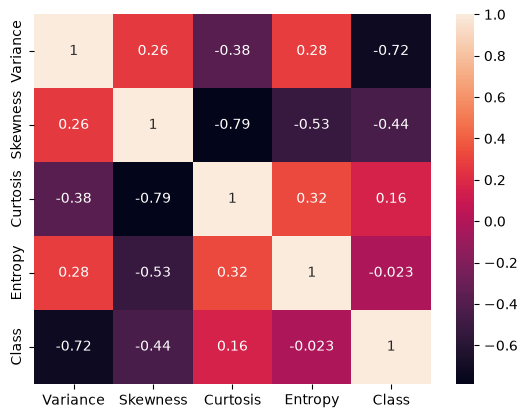

In [56]:
sns.heatmap(data.corr(),annot=True)

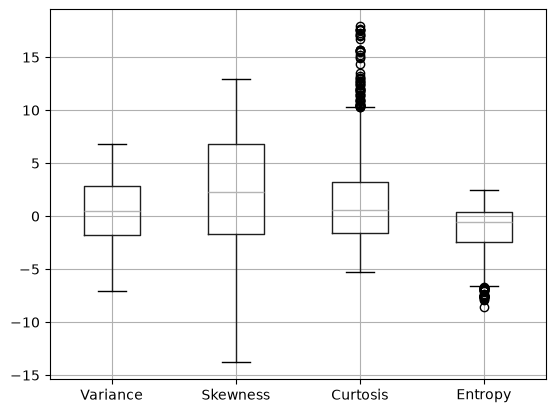

In [57]:
boxplot = data.boxplot(column=['Variance','Skewness','Curtosis','Entropy'])

<Axes: xlabel='Variance', ylabel='Count'>

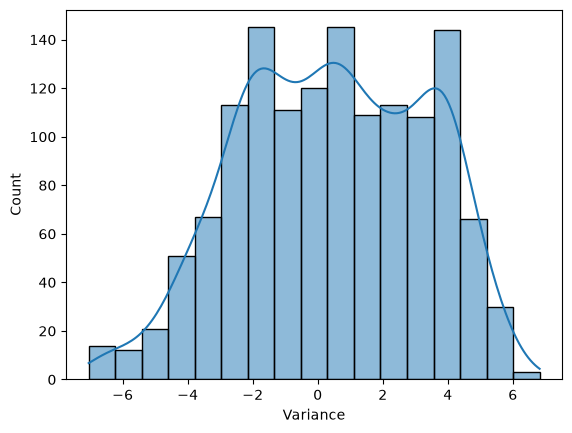

In [92]:
sns.histplot(data['Variance'], kde=True)

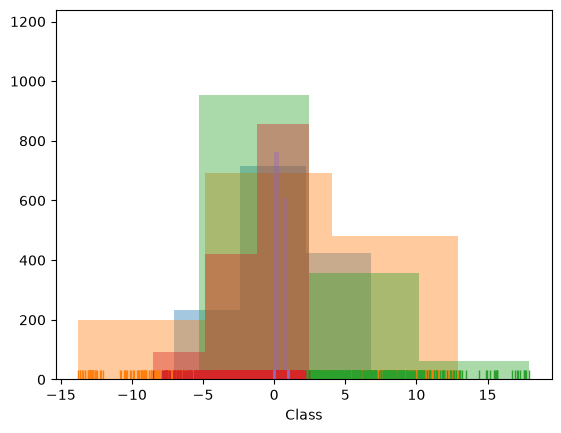

In [58]:
line_up=sns.distplot(data['Variance'], bins=3, kde=False, rug=True,label='Variance')
line_down=sns.distplot(data['Skewness'], bins=3, kde=False, rug=True,label = 'Skewness')
line_down=sns.distplot(data['Curtosis'], bins=3, kde=False, rug=True,label = 'Curtosis')
line_down=sns.distplot(data['Entropy'], bins=3, kde=False, rug=True,label = 'Entropy')
line_down=sns.distplot(data['Class'], bins=3, kde=False, rug=True,label = 'Class')

# **Classification**

In [59]:
#Splitting train and test datasets
X = data.drop(columns=['Class'])
y = data['Class']

X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## **Naïve Bayes**

In [84]:
#Creating a Gaussian Classifier
bayes = GaussianNB()

#Training the model using the training sets
bayes.fit(X_train,Y_train)

#Predicting the Output
y_pred_nb= bayes.predict(X_test)

acc_nb = accuracy_score(Y_test, y_pred_nb)
print(f"Naïve Bayes accuracy: {acc_nb:.3f}")

Naïve Bayes accuracy: 0.807


In [83]:
print("Naive Bayes")
print(confusion_matrix(Y_test, y_pred_nb))
print(classification_report(Y_test, y_pred_nb))

Naive Bayes
[[133  15]
 [ 38  89]]
              precision    recall  f1-score   support

           0       0.78      0.90      0.83       148
           1       0.86      0.70      0.77       127

    accuracy                           0.81       275
   macro avg       0.82      0.80      0.80       275
weighted avg       0.81      0.81      0.80       275



## **LDA**

In [88]:
#Creating a LDA Classifier
lda = LinearDiscriminantAnalysis()

#Training the model using the training sets
lda.fit(X_train,Y_train)

#Predicting the Output
y_pred_lda = lda.predict(X_test)

acc_lda = accuracy_score(Y_test, y_pred_lda)
print(f"LDA accuracy: {acc_lda:.3f}")

LDA accuracy: 0.978


In [89]:
print("LDA")
print(confusion_matrix(Y_test, y_pred_lda))
print(classification_report(Y_test, y_pred_lda))

LDA
[[142   6]
 [  0 127]]
              precision    recall  f1-score   support

           0       1.00      0.96      0.98       148
           1       0.95      1.00      0.98       127

    accuracy                           0.98       275
   macro avg       0.98      0.98      0.98       275
weighted avg       0.98      0.98      0.98       275



## **QDA**

In [90]:
#Creating a QDA Classifier
qda = QuadraticDiscriminantAnalysis()

#Training the model using the training sets
qda.fit(X_train, Y_train)

#Predicting the Output
y_pred_qda = qda.predict(X_test)

acc_qda  = accuracy_score(Y_test, y_pred_qda)
print(f"QDA accuracy: {acc_qda :.3f}")

QDA accuracy: 0.989


In [91]:
print("QDA")
print(confusion_matrix(Y_test, y_pred_qda))
print(classification_report(Y_test, y_pred_qda))

QDA
[[145   3]
 [  0 127]]
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       148
           1       0.98      1.00      0.99       127

    accuracy                           0.99       275
   macro avg       0.99      0.99      0.99       275
weighted avg       0.99      0.99      0.99       275



## **Model Comparison**

In [96]:
print("\nModel Comparison")
print(f"Naive Bayes: {acc_nb:.3f}")
print(f"LDA: {acc_lda:.3f}")
print(f"QDA: {acc_qda:.3f}")


Model Comparison
Naive Bayes: 0.807
LDA: 0.978
QDA: 0.989


Compared Naive Bayes, LDA, and QDA on a binary classification dataset and found that QDA achieved the highest accuracy due to its ability to model class-specific covariance structures.